🖼️ 데이터 제너레이터를 설정합니다...
Found 1821 images belonging to 3 classes.
Found 437 images belonging to 3 classes.
Found 440 images belonging to 3 classes.
총 클래스 개수: 3
클래스 이름: ['pasta', 'ramen', 'udon']

🤖 특징 추출기(Feature Extractor) 모델을 생성합니다...
✅ 특징 추출기 모델이 'food_feature_extractor.h5'에 저장되었습니다.

데이터셋에서 특징 추출을 시작합니다...
훈련 데이터 특징 추출 완료.
검증 데이터 특징 추출 완료.
테스트 데이터 특징 추출 완료.

추출된 특징 벡터 형태 (Train): (1821, 1280)

🚀 XGBoost 모델을 GPU로 훈련합니다...
[0]	validation_0-mlogloss:1.07528


C:\Users\user\anaconda3\envs\test\lib\site-packages\xgboost\core.py:158: UserWarning: [11:49:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
C:\Users\user\anaconda3\envs\test\lib\site-packages\xgboost\core.py:158: UserWarning: [11:49:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[1]	validation_0-mlogloss:1.05345
[2]	validation_0-mlogloss:1.03780
[3]	validation_0-mlogloss:1.02562
[4]	validation_0-mlogloss:1.01267
[5]	validation_0-mlogloss:0.99921
[6]	validation_0-mlogloss:0.98784
[7]	validation_0-mlogloss:0.97939
[8]	validation_0-mlogloss:0.97253
[9]	validation_0-mlogloss:0.96326
[10]	validation_0-mlogloss:0.95649
[11]	validation_0-mlogloss:0.94924
[12]	validation_0-mlogloss:0.94253
[13]	validation_0-mlogloss:0.93704
[14]	validation_0-mlogloss:0.93362
[15]	validation_0-mlogloss:0.93254
[16]	validation_0-mlogloss:0.92975
[17]	validation_0-mlogloss:0.92754
[18]	validation_0-mlogloss:0.92737
[19]	validation_0-mlogloss:0.92576
[20]	validation_0-mlogloss:0.92340
[21]	validation_0-mlogloss:0.92061
[22]	validation_0-mlogloss:0.91975
[23]	validation_0-mlogloss:0.91893
[24]	validation_0-mlogloss:0.92082
[25]	validation_0-mlogloss:0.91947
[26]	validation_0-mlogloss:0.91776
[27]	validation_0-mlogloss:0.91701
[28]	validation_0-mlogloss:0.91650
[29]	validation_0-mlogloss:0.

C:\Users\user\anaconda3\envs\test\lib\site-packages\xgboost\core.py:158: UserWarning: [11:49:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
C:\Users\user\anaconda3\envs\test\lib\site-packages\xgboost\core.py:158: UserWarning: [11:49:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the de

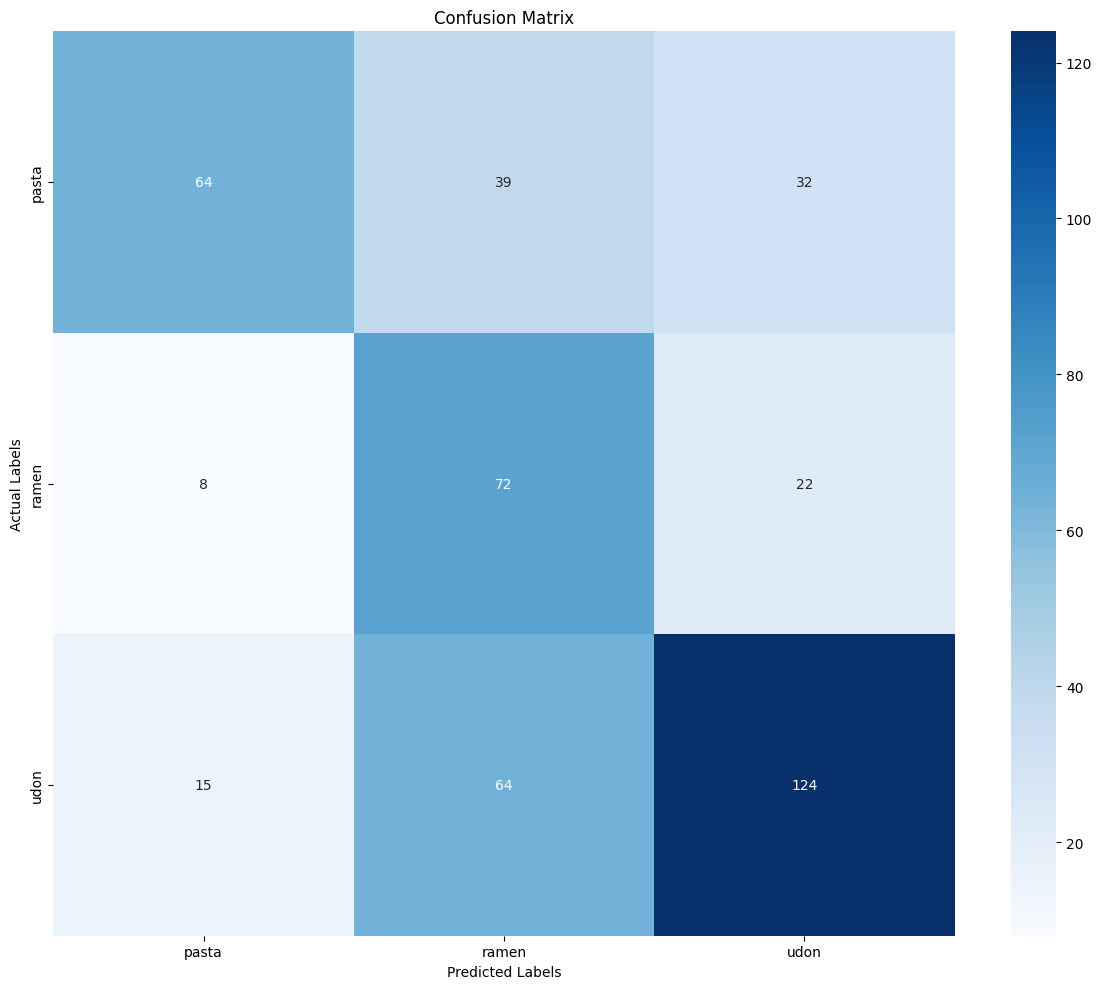


🎉 모든 과정이 완료되었습니다.


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import GlobalAveragePooling2D
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ==============================================================================
# 1. 기본 설정 및 경로 정의
# ==============================================================================
# 기본 경로 설정 (사용자 환경에 맞게 수정)
# 예: './food_dataset/' 안에 'train', 'valid', 'test' 폴더가 있다고 가정
# base_dir = './food_dataset/'
# train_dir = os.path.join(base_dir, 'train')
# valid_dir = os.path.join(base_dir, 'valid')
# test_dir = os.path.join(base_dir, 'test')

train_dir = 'E:/★★★★★AI★★★★★/음식 ai data/selectStart음식DATA/Computer Vision Lab/train'
valid_dir = 'E:/★★★★★AI★★★★★/음식 ai data/selectStart음식DATA/Computer Vision Lab/valid'
test_dir = 'E:/★★★★★AI★★★★★/음식 ai data/selectStart음식DATA/Computer Vision Lab/test' # 평가용 데이터셋 경로


# 모델 파라미터 설정
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 저장될 모델 파일 이름 정의
FEATURE_EXTRACTOR_PATH = 'food_feature_extractor.h5'
CLASSIFIER_PATH = 'food_classifier_model.json'


# ==============================================================================
# 2. ImageDataGenerator를 사용한 데이터 준비
# ==============================================================================
print("🖼️ 데이터 제너레이터를 설정합니다...")
# 훈련 데이터: 데이터 증강(Augmentation) 적용
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 검증 및 테스트 데이터: 증강 없이 스케일 조정만 적용
test_datagen = ImageDataGenerator(rescale=1./255)

# 데이터 제너레이터 생성
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 클래스 수 및 이름 확인
num_classes = len(train_generator.class_indices)
class_labels = list(train_generator.class_indices.keys())
print(f"총 클래스 개수: {num_classes}")
print(f"클래스 이름: {class_labels}")


# ==============================================================================
# 3. 전이 학습 모델 생성 및 저장
# ==============================================================================
print("\n🤖 특징 추출기(Feature Extractor) 모델을 생성합니다...")
# include_top=False: 분류기 레이어를 제외하고 불러옴
# weights='imagenet': ImageNet으로 사전 훈련된 가중치 사용
base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False # 가중치 동결

feature_extractor = Model(
    inputs=base_model.input,
    outputs=GlobalAveragePooling2D()(base_model.output)
)

# ✅ 특징 추출기 모델 저장
feature_extractor.save(FEATURE_EXTRACTOR_PATH)
print(f"✅ 특징 추출기 모델이 '{FEATURE_EXTRACTOR_PATH}'에 저장되었습니다.")


# ==============================================================================
# 4. 특징 추출 함수 정의 및 실행
# ==============================================================================
def extract_features(generator, model, sample_count):
    """ImageDataGenerator로부터 특징과 레이블을 추출하는 함수"""
    features = np.zeros(shape=(sample_count, model.output_shape[1]))
    labels = np.zeros(shape=(sample_count, num_classes))
    
    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = model.predict(inputs_batch, verbose=0)
        start_index = i * BATCH_SIZE
        end_index = start_index + features_batch.shape[0]

        features[start_index:end_index] = features_batch
        labels[start_index:end_index] = labels_batch
        i += 1
        if i * BATCH_SIZE >= sample_count:
            break
            
    # 레이블을 원-핫 인코딩에서 단일 정수로 변환
    return features, np.argmax(labels, axis=1)

# 각 데이터셋에서 특징 추출
print("\n데이터셋에서 특징 추출을 시작합니다...")
train_features, train_labels = extract_features(train_generator, feature_extractor, train_generator.samples)
print("훈련 데이터 특징 추출 완료.")
val_features, val_labels = extract_features(validation_generator, feature_extractor, validation_generator.samples)
print("검증 데이터 특징 추출 완료.")
test_features, test_labels = extract_features(test_generator, feature_extractor, test_generator.samples)
print("테스트 데이터 특징 추출 완료.")

print(f"\n추출된 특징 벡터 형태 (Train): {train_features.shape}")


# ==============================================================================
# 5. XGBoost 모델 훈련, 저장 및 평가
# ==============================================================================
print("\n🚀 XGBoost 모델을 GPU로 훈련합니다...")

# XGBoost 분류기 모델 생성
xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax',    # 다중 분류 문제
    num_class=num_classes,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=500,             # 트리의 개수
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='gpu_hist',        # ❗ GPU 가속 사용
    early_stopping_rounds=50 # 50 라운드 동안 성능 개선이 없으면 훈련 중지
)

# 조기 종료(Early Stopping)를 사용하여 최적의 트리 개수 찾기
xgb_classifier.fit(
    train_features,
    train_labels,
    eval_set=[(val_features, val_labels)],
    verbose=True
)

# ✅ 훈련된 XGBoost 모델 저장
print(f"\n✅ 훈련된 XGBoost 모델이 '{CLASSIFIER_PATH}'에 저장되었습니다.")
xgb_classifier.save_model(CLASSIFIER_PATH)


# ==============================================================================
# 6. 최종 성능 평가
# ==============================================================================
print("\n📊 테스트 데이터로 최종 성능을 평가합니다.")
y_pred = xgb_classifier.predict(test_features)
accuracy = accuracy_score(test_labels, y_pred)
print(f"✅ 최종 정확도: {accuracy * 100:.2f}%")

# 분류 리포트 출력
print("\nClassification Report:")
print(classification_report(test_labels, y_pred, target_names=class_labels))

# 혼동 행렬(Confusion Matrix) 시각화
print("\n혼동 행렬(Confusion Matrix)을 시각화합니다...")
cm = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.tight_layout()
plt.show()

print("\n🎉 모든 과정이 완료되었습니다.")

In [9]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import xgboost as xgb
import os

# --- 1. 기본 설정 및 모델 로드 ---
print("💾 모델을 로드합니다...")

# 저장된 모델 파일 경로
FEATURE_EXTRACTOR_PATH = 'food_feature_extractor.h5'
CLASSIFIER_PATH = 'food_classifier_model.json'
IMG_SIZE = (224, 224)

# 1-1. 특징 추출기(Keras 모델) 로드
feature_extractor = load_model(FEATURE_EXTRACTOR_PATH)

# 1-2. 분류기(XGBoost 모델) 로드
xgb_classifier = xgb.XGBClassifier()
xgb_classifier.load_model(CLASSIFIER_PATH)

print("✅ 모델 로드 완료.")


# --- 2. 클래스 레이블 정보 준비 ---
# ⚠️ 중요: 훈련 시 ImageDataGenerator가 생성한 클래스 순서와 동일해야 합니다.
# 폴더 이름의 알파벳 순서로 생성됩니다. (예: apple, banana, cherry 순)
# 사용자 본인의 클래스에 맞게 수정해주세요.
class_labels = {
    0: 'ramen',
    1: 'udon',
    2: 'pasta',
    # ... (가지고 있는 모든 클래스를 순서대로 추가)
}


# --- 3. 예측할 이미지 준비 및 전처리 ---
# 예측하고 싶은 새로운 이미지의 경로를 지정합니다.
image_path = 'E:/★★★★★AI★★★★★/음식 ai data/selectStart음식DATA/Computer Vision Lab/test2.png' # ❗ 이 경로를 수정하세요.

if not os.path.exists(image_path):
    print(f"오류: 이미지 파일을 찾을 수 없습니다. 경로를 확인하세요: {image_path}")
else:
    # 3-1. 이미지 로드 및 크기 조절
    img = load_img(image_path, target_size=IMG_SIZE)
    
    # 3-2. 이미지를 배열로 변환
    img_array = img_to_array(img)
    
    # 3-3. 0~1 사이로 스케일 조정 (훈련 때와 동일하게)
    img_array = img_array / 255.0
    
    # 3-4. 모델에 입력하기 위해 차원 확장 (배치 형태로 변환)
    # (224, 224, 3) -> (1, 224, 224, 3)
    img_batch = np.expand_dims(img_array, axis=0)
    

# --- 4. 예측 실행 ---
print(f"\n'{os.path.basename(image_path)}' 이미지 예측을 시작합니다...")

# 4-1. 특징 추출기를 이용해 이미지에서 특징 벡터 추출
features = feature_extractor.predict(img_batch)

# 4-2. 추출된 특징 벡터를 XGBoost 분류기에 넣어 "확률" 예측
# [0]을 붙여서 2차원 배열 -> 1차원 배열로 변환
probabilities = xgb_classifier.predict_proba(features)[0]


# --- 5. 결과 출력 ---
# 가장 확률이 높은 클래스의 인덱스(가장 유력한 예측)
predicted_class_index = np.argmax(probabilities)
predicted_class_name = class_labels.get(predicted_class_index, "알 수 없는 클래스")
confidence_score = probabilities[predicted_class_index]

print("\n" + "="*40)
print(f"✅ 최종 예측: 이 음식은 **{predicted_class_name}** 입니다.")
print(f"   (신뢰도: {confidence_score:.2%})") # 신뢰도를 퍼센트로 표시
print("="*40)

print("\n--- 모든 클래스별 확률 상세 ---")
for i, prob in enumerate(probabilities):
    class_name = class_labels.get(i, f"클래스 {i}")
    print(f"  - {class_name:<15}: {prob:.2%}") # 각 클래스의 확률을 퍼센트로 표시

💾 모델을 로드합니다...
✅ 모델 로드 완료.

'test2.png' 이미지 예측을 시작합니다...
1/1 [==============================] - 1s 878ms/step

✅ 최종 예측: 이 음식은 **pasta** 입니다.
   (신뢰도: 78.86%)

--- 모든 클래스별 확률 상세 ---
  - ramen          : 19.08%
  - udon           : 2.06%
  - pasta          : 78.86%
